# Task: Tensor Reshaping & Operations

#### 1.	Create a random tensor of shape (4, 6).

In [18]:
import tensorflow as tf

# 1. Create a random tensor of shape (4, 6)
tensor = tf.random.normal((4, 6))
print("Tensor \n", tensor)
print("\n")


# 2. Find rank and shape
print("Rank is :", tf.rank(tensor).numpy())
print("Shape is:", tf.shape(tensor).numpy())
print("\n")

# 3. Reshape to (2, 3, 4) and transpose to (3, 2, 4)
reshaped = tf.reshape(tensor, (2, 3, 4))
transposed = tf.transpose(reshaped, perm=[1, 0, 2])
print("Reshaped Shape:", reshaped.shape)
print("Transposed Shape:", transposed.shape)
print("\n")

# 4. Create smaller tensor and use broadcasting
small_tensor = tf.constant([[1.0, 2.0, 3.0, 4.0]])
result = transposed + small_tensor
print("\n\n")
print("Small Tensor Shape:", small_tensor.shape)
print("Result Shape:", result.shape)
print("Result:\n", result)



Tensor 
 tf.Tensor(
[[ 0.11875091 -1.4883575  -1.342071   -1.1906348  -0.4262396   2.8193543 ]
 [ 1.1647176  -0.4217545  -0.83911157 -0.8016814  -0.52062684 -2.1593866 ]
 [-0.15598628 -1.1176405  -1.7704021   1.6321703   1.4696937  -1.0036106 ]
 [-0.2776857  -0.7649808   1.9827074   0.04680779  0.36065033 -0.4894547 ]], shape=(4, 6), dtype=float32)


Rank is : 2
Shape is: [4 6]


Reshaped Shape: (2, 3, 4)
Transposed Shape: (3, 2, 4)





Small Tensor Shape: (1, 4)
Result Shape: (3, 2, 4)
Result:
 tf.Tensor(
[[[1.1187509  0.51164246 1.657929   2.8093653 ]
  [0.8440137  0.8823595  1.2295979  5.63217   ]]

 [[0.5737604  4.819354   4.1647177  3.5782454 ]
  [2.4696937  0.9963894  2.7223144  3.2350192 ]]

 [[0.16088843 1.1983186  2.4793732  1.8406134 ]
  [2.9827075  2.0468078  3.3606503  3.5105453 ]]], shape=(3, 2, 4), dtype=float32)


Broadcasting in TensorFlow allows two tensors with different shapes to work together in operations such as addition or multiplication. TensorFlow automatically expands the smaller tensor to match the larger tensor when their shapes are compatible. For example, a tensor with shape (1, 4) can be added to a tensor with shape (3, 2, 4). TensorFlow repeats the smaller tensor where needed instead of requiring us to manually copy it. This makes tensor operations easier and more efficient.

####  Task: Implement and Compare Loss Functions

Original MSE: 0.033333335
Changed MSE: 0.08333333
Original CCE: 0.28990924
Changed CCE: 0.5108256


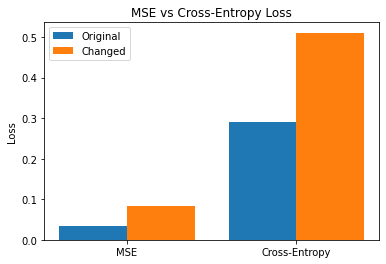

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt

# True values
y_true = tf.constant([[1, 0, 0],
                      [0, 1, 0]], dtype=tf.float32)

# Original predictions
y_pred1 = tf.constant([[0.8, 0.1, 0.1],
                       [0.2, 0.7, 0.1]], dtype=tf.float32)

# Changed predictions
y_pred2 = tf.constant([[0.6, 0.2, 0.2],
                       [0.3, 0.6, 0.1]], dtype=tf.float32)

# MSE
mse1 = tf.reduce_mean(tf.square(y_true - y_pred1))
mse2 = tf.reduce_mean(tf.square(y_true - y_pred2))

# Cross-Entropy
cce = tf.keras.losses.CategoricalCrossentropy()
cce1 = cce(y_true, y_pred1)
cce2 = cce(y_true, y_pred2)

# Print results
print("Original MSE:", mse1.numpy())
print("Changed MSE:", mse2.numpy())
print("Original CCE:", cce1.numpy())
print("Changed CCE:", cce2.numpy())

# Bar chart
labels = ["MSE", "Cross-Entropy"]
original = [mse1.numpy(), cce1.numpy()]
changed = [mse2.numpy(), cce2.numpy()]

x = range(2)

plt.bar([i - 0.2 for i in x], original, width=0.4, label="Original")
plt.bar([i + 0.2 for i in x], changed, width=0.4, label="Changed")

plt.xticks(x, labels)
plt.ylabel("Loss")
plt.title("MSE vs Cross-Entropy Loss")
plt.legend()
plt.show()

#### Task: Train MNIST Model with Adam & SGD

Epoch 1/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2887 - accuracy: 0.9176 - val_loss: 0.1564 - val_accuracy: 0.9548
Epoch 2/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.1311 - accuracy: 0.9620 - val_loss: 0.1171 - val_accuracy: 0.9641
Epoch 3/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0910 - accuracy: 0.9726 - val_loss: 0.1032 - val_accuracy: 0.9693
Epoch 4/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0668 - accuracy: 0.9794 - val_loss: 0.1043 - val_accuracy: 0.9678
Epoch 5/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0510 - accuracy: 0.9847 - val_loss: 0.0894 - val_accuracy: 0.9739
Epoch 1/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.7263 - accuracy: 0.8163 - val_loss: 0.3816 - val_accuracy: 0.8991
Epoch 2/5
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3684 - accuracy: 0.8966 - val_loss: 0.3126 - val_accuracy: 0.9137

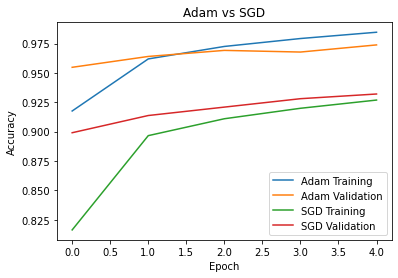

In [23]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train = x_train / 255.0
x_test = x_test / 255.0


# -------- ADAM MODEL --------
adam_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

adam_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

adam_history = adam_model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2
)


# -------- SGD MODEL --------
sgd_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

sgd_model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

sgd_history = sgd_model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2
)


# -------- COMPARE BOTH MODELS --------
plt.plot(adam_history.history["accuracy"], label="Adam Training")
plt.plot(adam_history.history["val_accuracy"], label="Adam Validation")

plt.plot(sgd_history.history["accuracy"], label="SGD Training")
plt.plot(sgd_history.history["val_accuracy"], label="SGD Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam vs SGD")
plt.legend()
plt.show()

##### 	Train a Neural Network and Log to TensorBoard

In [1]:
import tensorflow as tf

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Create a simple neural network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# TensorBoard log location
tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir="logs/fit/"
)

# Train for 5 epochs
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    callbacks=[tensorboard]
)


Epoch 1/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2890 - accuracy: 0.9171 - val_loss: 0.1504 - val_accuracy: 0.9563
Epoch 2/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1268 - accuracy: 0.9628 - val_loss: 0.1136 - val_accuracy: 0.9642
Epoch 3/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0860 - accuracy: 0.9741 - val_loss: 0.0968 - val_accuracy: 0.9680
Epoch 4/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0635 - accuracy: 0.9813 - val_loss: 0.0873 - val_accuracy: 0.9734
Epoch 5/5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0484 - accuracy: 0.9854 - val_loss: 0.0878 - val_accuracy: 0.9743


In [2]:
%load_ext tensorboard
%tensorboard --logdir logs/fit/


Reusing TensorBoard on port 6006 (pid 31464), started 0:03:36 ago. (Use '!kill 31464' to kill it.)

### 1. What patterns do you observe in the training and validation accuracy curves?

The training accuracy increases as the model learns from the data. The validation accuracy also increases, showing that the model is improving on data it has not seen during training. If both curves continue to increase and stay relatively close to each other, it means the model is learning well.

### 2. How can you use TensorBoard to detect overfitting?

TensorBoard can help identify overfitting by comparing the training and validation curves. If the training accuracy continues to increase while the validation accuracy stops improving or begins to decrease, the model may be overfitting. A similar pattern can be seen with loss when training loss decreases but validation loss starts increasing.

### 3. What happens when you increase the number of epochs?

Increasing the number of epochs gives the model more time to learn from the training data. At first, this can improve its accuracy. However, if the model is trained for too many epochs, it may start memorizing the training data instead of learning general patterns. This can cause overfitting, where training accuracy remains high but validation accuracy gets worse.

In [3]:
pwd

'C:\\Users\\FROST'